# Which branch moved?

**Week 1, Tuesday. Notebook 2 of 5, round 2.** By the end of this notebook you can split the
quarter's fall along the revenue tree, say in rupees how much each branch carries, and answer
Marketing's claim about customers with a count.

> **The client asks.** "Are we losing customers, or are the ones we have buying less? Marketing
> says more customers. Prove it or disprove it."
>
> Meera Raghavan, CEO, Kalpa Retail

Round 1 confirmed the drop on matched windows: two closed quarters of thirteen weeks each, revenue
from Rs 2,10,00,000 to Rs 1,87,00,000, which is Rs 23,00,000 and 11.0 percent. Marketing's
25.9 percent was an eleven-week tile set against a full quarter. This round asks which branch of
the tree the Rs 23,00,000 sits on.

> **Kavya's review of round 1.** "Good: you said both windows before you said a percentage. Now
> stop describing the fall and start taking it apart."

**Setup.** The walk-up import finds `c2kit`, the export loads, and a dictionary keyed by quarter
holds each quarter's orders, so every later cell can ask for `by_quarter["Q1"]` by name.

In [1]:
import sys, pathlib
here = pathlib.Path.cwd()
for parent in [here, *here.parents]:
    if (parent / "scripts" / "c2kit.py").exists():
        sys.path.insert(0, str(parent / "scripts")); break
import c2kit as kit
ORDERS = kit.load_records("C2_W01_D02_orders_STUDENT.py")
by_quarter = {"Q1": [], "Q2": []}
for order in ORDERS:
    by_quarter[order["quarter"]].append(order)
print(len(by_quarter["Q1"]), "orders in Q1 and", len(by_quarter["Q2"]), "in Q2")

114 orders in Q1 and 86 in Q2


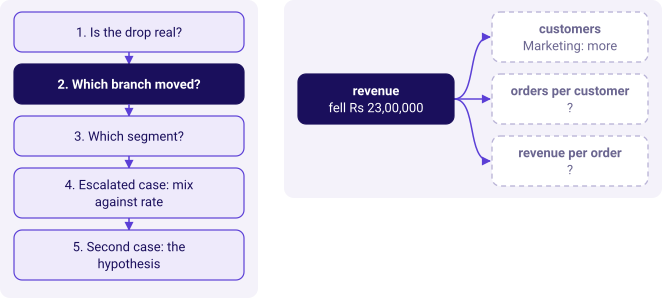

In [2]:
kit.side_by_side(
    kit.ladder(["Is the drop real?", "Which branch moved?", "Which segment?", "Escalated case: mix against rate", "Second case: the hypothesis"], lit=1, show=False),
    kit.driver_tree({"label": "revenue", "note": "fell Rs 23,00,000", "kind": "lit", "children": [
        {"label": "customers", "note": "Marketing: more", "kind": "unknown"},
        {"label": "orders per customer", "note": "?", "kind": "unknown"},
        {"label": "revenue per order", "note": "?", "kind": "unknown"}]}, show=False),
)

## 1. Customers held at 69 in both quarters

Marketing's claim is about the first branch, so it is counted first. A dictionary per quarter maps
each customer id to the orders that customer placed. `.get(cid, 0)` reads the count so far and
supplies 0 when the id has not appeared yet, and that default is right for a reason worth writing
down: a customer not seen yet in the quarter has placed no orders in it so far.

**Predict before you run.** How did the number of distinct customers move from Q1 to Q2? a) it
fell; b) it held; c) it rose, as Marketing says; d) it cannot be told without the segments.

Quarter,Distinct customers,Orders
Q1,69,114
Q2,69,86


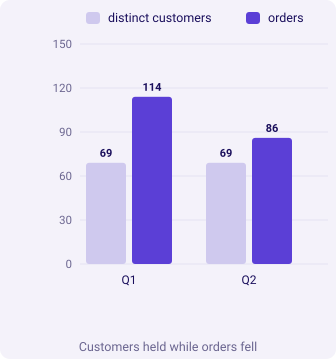

In [3]:
orders_by_customer = {"Q1": {}, "Q2": {}}      # quarter -> {customer_id: orders placed}
for q in by_quarter:
    for order in by_quarter[q]:
        cid = order["customer_id"]
        # default: a customer not seen yet in this quarter has placed zero orders in it so far
        orders_by_customer[q][cid] = orders_by_customer[q].get(cid, 0) + 1

customers = {}
orders = {}
for q in by_quarter:
    customers[q] = len(orders_by_customer[q])
    orders[q] = len(by_quarter[q])

kit.table(["Quarter", "Distinct customers", "Orders"],
          [("Q1", customers["Q1"], orders["Q1"]), ("Q2", customers["Q2"], orders["Q2"])],
          caption="The first branch, counted")
kit.columns(["Q1", "Q2"], [("distinct customers", [customers["Q1"], customers["Q2"]]),
                           ("orders", [orders["Q1"], orders["Q2"]])],
            title="Customers held while orders fell")

**What happened.** The answer is b. Kalpa had 69 distinct customers in each quarter, so the count
does not support "more customers". Orders fell from 114 to 86 on the same count, which already
points at the second branch. Whether the 69 are the same people in both quarters is a separate
question, and the afternoon's second case tests it.

In [4]:
total_q1 = 0
for cid in orders_by_customer["Q1"]:
    total_q1 += orders_by_customer["Q1"][cid]
kit.check("customers held at 69 in both quarters", customers["Q1"] == customers["Q2"] == 69,
          f'{customers["Q1"]} and {customers["Q2"]}')
kit.check("the per-customer counts add back to Q1's orders", total_q1 == orders["Q1"], f"{total_q1}")
kit.check("orders fell by 28", orders["Q1"] - orders["Q2"] == 28, f'{orders["Q1"]} to {orders["Q2"]}')

## 2. Orders per customer carries the fall, and revenue per order rose

The tree multiplies three leaves: customers, orders per customer, and revenue per order. With the
first leaf flat, the fall has to sit in one or both of the other two.

**Predict before you run.** Which leaf moved against Kalpa? a) customers; b) orders per customer;
c) revenue per order; d) all three fell a little.

Leaf,Q1,Q2,Change
customers,69,69,0.0%
orders per customer,1.65,1.25,-24.6%
revenue per order,"Rs 1,84,211","Rs 2,17,442",+18.0%
revenue per customer,"Rs 3,04,348","Rs 2,71,014",-11.0%


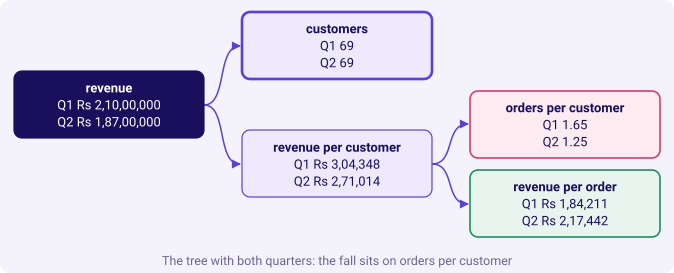

In [5]:
revenue = {"Q1": 0, "Q2": 0}
for q in by_quarter:
    for order in by_quarter[q]:
        revenue[q] += order["amount"]

opc = {}     # orders per customer
rpo = {}     # revenue per order
for q in by_quarter:
    opc[q] = orders[q] / customers[q]
    rpo[q] = revenue[q] / orders[q]

kit.table(["Leaf", "Q1", "Q2", "Change"],
          [("customers", customers["Q1"], customers["Q2"], f'{(customers["Q2"] / customers["Q1"] - 1) * 100:.1f}%'),
           ("orders per customer", f'{opc["Q1"]:.2f}', f'{opc["Q2"]:.2f}', f'{(opc["Q2"] / opc["Q1"] - 1) * 100:.1f}%'),
           ("revenue per order", kit.rupees(round(rpo["Q1"])), kit.rupees(round(rpo["Q2"])), f'{(rpo["Q2"] / rpo["Q1"] - 1) * 100:+.1f}%'),
           ("revenue per customer", kit.rupees(round(revenue["Q1"] / 69)), kit.rupees(round(revenue["Q2"] / 69)), f'{(revenue["Q2"] / revenue["Q1"] - 1) * 100:.1f}%')],
          caption="The tree's leaves in both quarters")
kit.driver_tree({"label": "revenue", "note": f'Q1 {kit.rupees(revenue["Q1"])}\nQ2 {kit.rupees(revenue["Q2"])}', "kind": "lit", "children": [
    {"label": "customers", "note": f'Q1 {customers["Q1"]}\nQ2 {customers["Q2"]}', "kind": "known"},
    {"label": "revenue per customer", "note": f'Q1 {kit.rupees(round(revenue["Q1"] / 69))}\nQ2 {kit.rupees(round(revenue["Q2"] / 69))}', "children": [
        {"label": "orders per customer", "note": f'Q1 {opc["Q1"]:.2f}\nQ2 {opc["Q2"]:.2f}', "kind": "bad"},
        {"label": "revenue per order", "note": f'Q1 {kit.rupees(round(rpo["Q1"]))}\nQ2 {kit.rupees(round(rpo["Q2"]))}', "kind": "good"}]}]},
    title="The tree with both quarters: the fall sits on orders per customer", width_per=190)

**What happened.** The answer is b. Orders per customer fell from 1.65 to 1.25, a fall of
24.6 percent, while revenue per order rose 18.0 percent, from Rs 1,84,211 to Rs 2,17,442. The same
69 customers placed fewer orders, and the orders they placed were larger on average. The leaves
must multiply back to the change in revenue, and the next cell proves that they do.

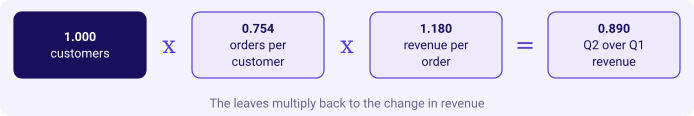

In [6]:
ratio_c = customers["Q2"] / customers["Q1"]
ratio_f = opc["Q2"] / opc["Q1"]
ratio_v = rpo["Q2"] / rpo["Q1"]
kit.equation([f"{ratio_c:.3f}\ncustomers", "x", f"{ratio_f:.3f}\norders per customer", "x",
              f"{ratio_v:.3f}\nrevenue per order", "=", f"{ratio_c * ratio_f * ratio_v:.3f}\nQ2 over Q1 revenue"],
             title="The leaves multiply back to the change in revenue")
kit.check("the three ratios multiply to Q2 over Q1 revenue",
          abs(ratio_c * ratio_f * ratio_v - revenue["Q2"] / revenue["Q1"]) < 1e-9,
          f'{ratio_c * ratio_f * ratio_v:.3f} and {revenue["Q2"] / revenue["Q1"]:.3f}')
kit.check("orders per customer fell 24.6 percent", round((ratio_f - 1) * 100, 1) == -24.6, f"{(ratio_f - 1) * 100:.2f}")
kit.check("revenue per order rose 18.0 percent", round((ratio_v - 1) * 100, 1) == 18.0, f"{(ratio_v - 1) * 100:.2f}")

## 3. In rupees, frequency costs Rs 51,57,895 and bigger orders give back Rs 28,57,895

Percentages on leaves do not add up, rupees do. The bridge changes one leaf at a time, in the
order of the tree: first customers, holding the other two at Q1; then orders per customer; then
revenue per order. Each step's rupees are the change in revenue that one leaf makes.

**Predict before you run.** How many rupees does the fall in orders per customer take away?
a) Rs 23,00,000; b) Rs 51,57,895; c) Rs 28,57,895; d) nothing, because customers held.

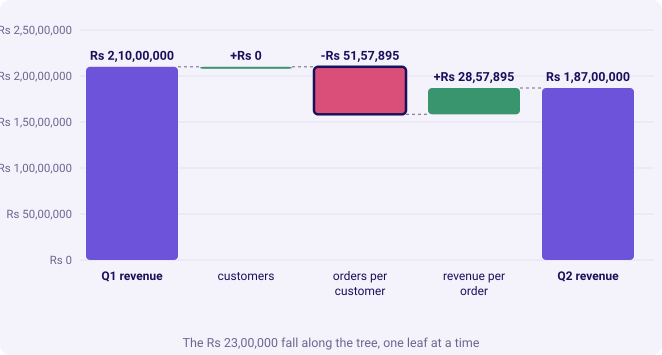

Leaf changed,Rupees,Read as
customers,Rs 0,69 to 69: no change
orders per customer,"-Rs 51,57,895",28 fewer orders at the Q1 revenue per order
revenue per order,"Rs 28,57,895","86 orders, each Rs 33,231 larger"


In [7]:
move_customers = (customers["Q2"] - customers["Q1"]) * opc["Q1"] * rpo["Q1"]
move_frequency = customers["Q2"] * (opc["Q2"] - opc["Q1"]) * rpo["Q1"]
move_order_value = customers["Q2"] * opc["Q2"] * (rpo["Q2"] - rpo["Q1"])

kit.bridge(("Q1 revenue", revenue["Q1"]),
           [("customers", round(move_customers)),
            ("orders per customer", round(move_frequency)),
            ("revenue per order", round(move_order_value))],
           end_label="Q2 revenue", lit=[1],
           title="The Rs 23,00,000 fall along the tree, one leaf at a time")
kit.table(["Leaf changed", "Rupees", "Read as"],
          [("customers", kit.rupees(round(move_customers)), f'{customers["Q1"]} to {customers["Q2"]}: no change'),
           ("orders per customer", kit.rupees(round(move_frequency)), f'{orders["Q1"] - orders["Q2"]} fewer orders at the Q1 revenue per order'),
           ("revenue per order", kit.rupees(round(move_order_value)), f'{orders["Q2"]} orders, each {kit.rupees(round(rpo["Q2"] - rpo["Q1"]))} larger')],
          caption="The bridge's moves")

In [8]:
kit.check("the bridge lands on Q2 revenue",
          abs(revenue["Q1"] + move_customers + move_frequency + move_order_value - revenue["Q2"]) < 1,
          kit.rupees(revenue["Q2"]))
kit.check("the frequency move is 28 orders at Q1's revenue per order",
          abs(move_frequency - (-28 * rpo["Q1"])) < 1, kit.rupees(round(move_frequency)))
kit.check("the customers move is zero", move_customers == 0)

**What happened.** The answer is b. Holding customers and order value at Q1, the fall in orders
per customer takes away Rs 51,57,895, which is 28 fewer orders at Rs 1,84,211 each. Larger orders
give back Rs 28,57,895. The customer branch contributes nothing, so Marketing's case for
acquisition has no rupees behind it on this file.

> **Kavya's review.** "Meera asked two questions and you have answered both with a count: customers
> held at 69, and the ones we have bought less often. Put the bridge in front of her, and do not
> call the rise in order value good news until you know where it came from."

### The order of the steps is a choice

The bridge above moved frequency first, holding order value at Q1. Move order value first instead,
holding orders at Q1, and the same Rs 23,00,000 splits differently: the frequency step is then priced
at Q2's larger orders. The two branches moved at the same time, and whichever goes second is charged
for the part where they overlap. A symmetric split avoids choosing: the revenue ratio is the product
of the branch ratios, so its logarithm is the sum of theirs, and each branch takes its share of the
rupee change in proportion to its logarithm (B. W. Ang, "The LMDI approach to decomposition analysis:
a practical guide", Energy Policy, 2005, checked through Crossref 29 Sep 2026).

**Predict before you run.** Moved second, at Q2's revenue per order, does the frequency step cost
a) the same Rs 51,57,895; b) more, about Rs 61 lakh; c) less, about Rs 42 lakh; d) nothing?

Order of the steps,Orders per customer,Revenue per order,Sum
frequency first,"-Rs 51,57,895","Rs 28,57,895","-Rs 23,00,000"
order value first,"-Rs 60,88,372","Rs 37,88,372","-Rs 23,00,000"
"symmetric, logarithmic","-Rs 55,88,480","Rs 32,88,480","-Rs 23,00,000"


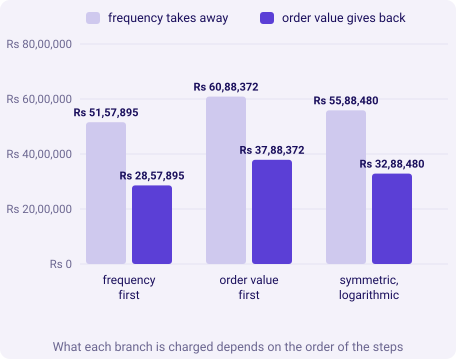

In [9]:
import math

# Order A, as above: frequency first at Q1's revenue per order, then order value on Q2's orders
a_freq = customers["Q2"] * (opc["Q2"] - opc["Q1"]) * rpo["Q1"]
a_value = orders["Q2"] * (rpo["Q2"] - rpo["Q1"])
# Order B: order value first on Q1's orders, then frequency at Q2's revenue per order
b_value = orders["Q1"] * (rpo["Q2"] - rpo["Q1"])
b_freq = customers["Q2"] * (opc["Q2"] - opc["Q1"]) * rpo["Q2"]
# Symmetric: the logarithmic mean of the two revenues, times each branch's log change
log_mean = (revenue["Q2"] - revenue["Q1"]) / math.log(revenue["Q2"] / revenue["Q1"])
s_freq = log_mean * math.log(opc["Q2"] / opc["Q1"])
s_value = log_mean * math.log(rpo["Q2"] / rpo["Q1"])

splits = [("frequency first", a_freq, a_value),
          ("order value first", b_freq, b_value),
          ("symmetric, logarithmic", s_freq, s_value)]
rows, names, takes, gives = [], [], [], []
for name, f, v in splits:
    rows.append((name, kit.rupees(round(f)), kit.rupees(round(v)), kit.rupees(round(f + v))))
    names.append(name)
    takes.append(-f)
    gives.append(v)
kit.table(["Order of the steps", "Orders per customer", "Revenue per order", "Sum"], rows,
          caption="One fall, three honest splits")
kit.columns(names, [("frequency takes away", takes), ("order value gives back", gives)],
            fmt=lambda v: kit.rupees(round(v)),
            title="What each branch is charged depends on the order of the steps")

In [10]:
for name, f, v in splits:
    kit.check(f"{name}: the two steps sum to the Rs 23,00,000 fall",
              abs(f + v - (revenue["Q2"] - revenue["Q1"])) < 1, kit.rupees(round(f + v)))
kit.check("moved second, the frequency step costs Rs 60,88,372", round(b_freq) == -6088372,
          kit.rupees(round(b_freq)))
kit.check("the symmetric split sits between the two orders", b_freq < s_freq < a_freq,
          kit.rupees(round(s_freq)))

**What happened.** The answer is b. Moved second, the 28 lost orders are priced at Q2's
Rs 2,17,442, so frequency costs Rs 60,88,372 and order value gives back Rs 37,88,372. The symmetric
split charges frequency Rs 55,88,480 and credits order value Rs 32,88,480. All three land on the same
fall, and in every one frequency is the branch that cost money, so the decision does not change. What
changes is the figure a reader will try to rebuild: write the order beside the bridge, or use the
symmetric split so the answer does not depend on it.

## 4. The discount branch, read the hurried way, points the wrong way

Meera's tree has one more branch that Marketing likes: "we cut discounts, so people bought less".
The export carries a `discount` field in rupees, so the first attempt adds it up by quarter.

In [11]:
with kit.expect_error() as err:
    given = 0
    for order in ORDERS:
        given += order["discount"]
kit.check("the loop stopped on a missing key", err.name == "KeyError", f"{err.name}: {err.message}")

That is a runtime error, and it takes two minutes: some records do not carry a `discount` key at
all, and indexing a dictionary with a key it lacks raises `KeyError`. A `try` and `except KeyError`
around the line would also get past it. The question that matters is what a missing discount
means.

**Predict before you run.** A hurried analyst reads every missing discount as zero. What will the
totals say? a) discounts rose; b) discounts fell a little; c) discounts halved; d) nothing, because
the missing records cancel out.

**The plausible wrong answer.** `.get("discount", 0)` makes the error go away and gives a number.

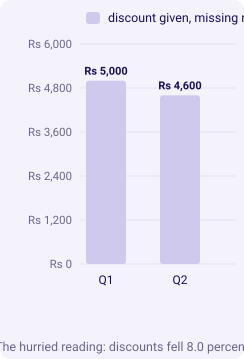

In [12]:
given = {"Q1": 0, "Q2": 0}
for q in by_quarter:
    for order in by_quarter[q]:
        given[q] += order.get("discount", 0)       # the hurried default: missing becomes zero

hurried_change = (given["Q2"] - given["Q1"]) / given["Q1"] * 100
as_zero_avg = {"Q1": given["Q1"] / orders["Q1"], "Q2": given["Q2"] / orders["Q2"]}
kit.stats([(kit.rupees(given["Q1"]), "discount given, Q1", "missing read as zero"),
           (kit.rupees(given["Q2"]), "discount given, Q2", "missing read as zero"),
           (f"{hurried_change:.1f}%", "the hurried change", "so, restore the discounts?")])
kit.columns(["Q1", "Q2"], [("discount given, missing read as zero", [given["Q1"], given["Q2"]])],
            fmt=kit.rupees, title="The hurried reading: discounts fell 8.0 percent")

**Why it is wrong.** The answer to the prediction is b, and it is the wrong conclusion. A record
with no discount field is a record where nobody wrote the discount down; the discount is unknown.
Adding those records as zero turns the total into a floor, and dividing by every order drags each
quarter's average down by however many records happen to be blank. The decision it misleads is
expensive: "discounts fell, members pulled back, restore the discounts" spends margin on a branch
the data has not shown moved.

The mechanism on three **invented** orders, one with Rs 100 off, one with Rs 0 off, and one with no
field at all:

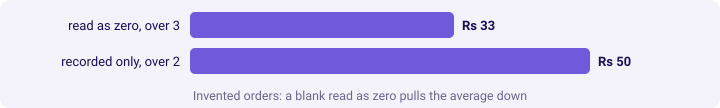

In [13]:
invented = [{"order_id": "INVENTED-1", "discount": 100},
            {"order_id": "INVENTED-2", "discount": 0},
            {"order_id": "INVENTED-3"}]                      # invented records, no discount field on the third

as_zero = 0
recorded_sum = 0
recorded_n = 0
for order in invented:
    as_zero += order.get("discount", 0)
    if "discount" in order:
        recorded_sum += order["discount"]
        recorded_n += 1
kit.bars([("read as zero, over 3", round(as_zero / 3)), ("recorded only, over 2", round(recorded_sum / recorded_n))],
         fmt=kit.rupees, title="Invented orders: a blank read as zero pulls the average down")
kit.check("on the invented orders, read-as-zero averages Rs 33 and recorded-only Rs 50",
          (round(as_zero / 3), recorded_sum / recorded_n) == (33, 50))

**Your turn.** Count the Kalpa records that carry no `discount` field, in each quarter. Type these
lines into the empty cell below and run them, then say in one sentence what share of each quarter
the hurried total treated as zero:

```python
missing = {"Q1": 0, "Q2": 0}
for order in ORDERS:
    if "discount" not in order:
        missing[order["quarter"]] += 1
print(missing)
```

**The check.** Average the discount only over the orders that recorded one, and compare the
direction with the hurried reading.

Measure,Q1,Q2,Direction
"average per order, missing read as zero",Rs 43.86,Rs 53.49,up
average where the discount is recorded,Rs 60.98,Rs 76.67,up 25.7%
"total, missing read as zero","Rs 5,000","Rs 4,600",down 8.0%


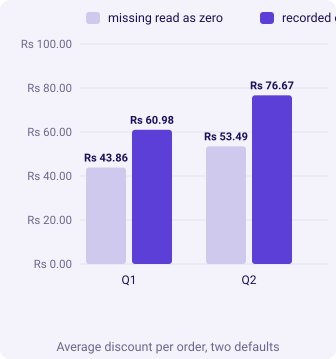

In [14]:
recorded_sum = {"Q1": 0, "Q2": 0}
recorded_n = {"Q1": 0, "Q2": 0}
largest = 0
for q in by_quarter:
    for order in by_quarter[q]:
        if "discount" in order:
            recorded_sum[q] += order["discount"]
            recorded_n[q] += 1
            if order["discount"] > largest:
                largest = order["discount"]

recorded_avg = {"Q1": recorded_sum["Q1"] / recorded_n["Q1"], "Q2": recorded_sum["Q2"] / recorded_n["Q2"]}
recorded_change = (recorded_avg["Q2"] - recorded_avg["Q1"]) / recorded_avg["Q1"] * 100
kit.table(["Measure", "Q1", "Q2", "Direction"],
          [("average per order, missing read as zero", f'Rs {as_zero_avg["Q1"]:.2f}', f'Rs {as_zero_avg["Q2"]:.2f}', "up"),
           ("average where the discount is recorded", f'Rs {recorded_avg["Q1"]:.2f}', f'Rs {recorded_avg["Q2"]:.2f}', f"up {recorded_change:.1f}%"),
           ("total, missing read as zero", kit.rupees(given["Q1"]), kit.rupees(given["Q2"]), f"down {-hurried_change:.1f}%")],
          caption="Where the discount is recorded, it went up")
kit.columns(["Q1", "Q2"], [("missing read as zero", [round(as_zero_avg["Q1"], 2), round(as_zero_avg["Q2"], 2)]),
                           ("recorded only", [round(recorded_avg["Q1"], 2), round(recorded_avg["Q2"], 2)])],
            fmt=lambda v: f"Rs {v:.2f}", title="Average discount per order, two defaults")
kit.check("the recorded-only average rose 25.7 percent", round(recorded_change, 1) == 25.7, f"{recorded_change:.2f}")
kit.check("the hurried total and the recorded average point in opposite directions",
          hurried_change < 0 < recorded_change)
kit.check("the largest recorded discount is Rs 150", largest == 150, kit.rupees(largest))

**The fix.** Write the default and its reason where the next person will read it: an absent
discount means not recorded; it is reported separately and never summed as zero. Then bound the
branch. The largest discount anyone recorded is Rs 150, so even if every one of Q2's 86 orders had
carried Rs 150 off, the branch could hold at most Rs 12,900 against a fall of Rs 23,00,000.

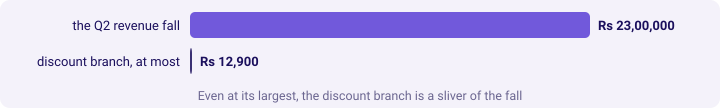

The rule, written down: absent means not recorded; reported separately; never summed as zero


In [15]:
DISCOUNT_RULE = "absent means not recorded; reported separately; never summed as zero"
bound = orders["Q2"] * largest
kit.bars([("the Q2 revenue fall", revenue["Q1"] - revenue["Q2"]), ("discount branch, at most", bound)],
         fmt=kit.rupees, lit=[1], title="Even at its largest, the discount branch is a sliver of the fall")
kit.check("the discount branch is under one percent of the fall", bound / (revenue["Q1"] - revenue["Q2"]) < 0.01,
          f'{kit.rupees(bound)} of {kit.rupees(revenue["Q1"] - revenue["Q2"])}')
print("The rule, written down:", DISCOUNT_RULE)

**What changed.** "Discounts fell 8.0 percent, restore them" became "where recorded, the average
discount rose 25.7 percent, and the whole branch is worth at most Rs 12,900". The discount branch
leaves the list of causes, and no margin is spent on it.

## 5. On delivered orders only, frequency still carries the fall

The room's variant uses Anand's definition, orders that reached the customer and stayed there, and
runs the same tree again.

**Predict before you run.** On delivered orders only, which leaf moves most? a) customers;
b) orders per customer; c) revenue per order; d) none, the fall disappears.

Delivered only,Q1,Q2,Change
revenue,"Rs 1,45,04,970","Rs 1,28,64,680",-11.3%
customers,54,50,-7.4%
orders,81,57,-29.6%
orders per customer,1.50,1.14,-24.0%
revenue per order,"Rs 1,79,074","Rs 2,25,696",+26.0%


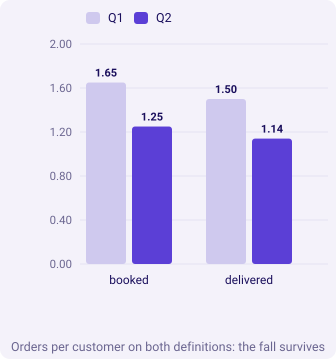

In [16]:
d_rev = {"Q1": 0, "Q2": 0}
d_orders = {"Q1": 0, "Q2": 0}
d_seen = {"Q1": {}, "Q2": {}}
for q in by_quarter:
    for order in by_quarter[q]:
        if order["status"] == "delivered":
            d_rev[q] += order["amount"]
            d_orders[q] += 1
            d_seen[q][order["customer_id"]] = True

d_cust = {"Q1": len(d_seen["Q1"]), "Q2": len(d_seen["Q2"])}
d_opc = {"Q1": d_orders["Q1"] / d_cust["Q1"], "Q2": d_orders["Q2"] / d_cust["Q2"]}
d_rpo = {"Q1": d_rev["Q1"] / d_orders["Q1"], "Q2": d_rev["Q2"] / d_orders["Q2"]}
kit.table(["Delivered only", "Q1", "Q2", "Change"],
          [("revenue", kit.rupees(d_rev["Q1"]), kit.rupees(d_rev["Q2"]), f'{(d_rev["Q2"] / d_rev["Q1"] - 1) * 100:.1f}%'),
           ("customers", d_cust["Q1"], d_cust["Q2"], f'{(d_cust["Q2"] / d_cust["Q1"] - 1) * 100:.1f}%'),
           ("orders", d_orders["Q1"], d_orders["Q2"], f'{(d_orders["Q2"] / d_orders["Q1"] - 1) * 100:.1f}%'),
           ("orders per customer", f'{d_opc["Q1"]:.2f}', f'{d_opc["Q2"]:.2f}', f'{(d_opc["Q2"] / d_opc["Q1"] - 1) * 100:.1f}%'),
           ("revenue per order", kit.rupees(round(d_rpo["Q1"])), kit.rupees(round(d_rpo["Q2"])), f'{(d_rpo["Q2"] / d_rpo["Q1"] - 1) * 100:+.1f}%')],
          caption="The tree on Anand's definition")
kit.columns(["booked", "delivered"], [("Q1", [round(opc["Q1"], 2), round(d_opc["Q1"], 2)]),
                                      ("Q2", [round(opc["Q2"], 2), round(d_opc["Q2"], 2)])],
            fmt=lambda v: f"{v:.2f}", title="Orders per customer on both definitions: the fall survives")

**What happened.** The answer is b. On delivered orders revenue fell 11.3 percent, from
Rs 1,45,04,970 to Rs 1,28,64,680. Customers moved from 54 to 50, and orders per customer fell from
1.50 to 1.14, 24.0 percent, while revenue per order rose 26.0 percent. The definition changes every
number and leaves the finding standing: the same customers bought less often. You have now written
the same accumulating loop three times, which is what round 3 turns into a function.

In [17]:
kit.check("delivered revenue fell 11.3 percent", round((d_rev["Q2"] / d_rev["Q1"] - 1) * 100, 1) == -11.3)
kit.check("delivered orders per customer fell 24.0 percent", round((d_opc["Q2"] / d_opc["Q1"] - 1) * 100, 1) == -24.0,
          f'{d_opc["Q1"]:.2f} to {d_opc["Q2"]:.2f}')
kit.check("delivered orders are a subset of booked orders", d_orders["Q1"] <= orders["Q1"] and d_orders["Q2"] <= orders["Q2"])

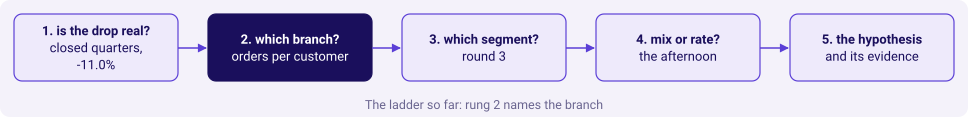

Finding,Number,Decision it supports
customers held,69 and 69,acquisition is not the branch that moved
orders per customer fell,"1.65 to 1.25, -Rs 51,57,895",frequency is the branch to open
revenue per order rose,"+18.0%, +Rs 28,57,895",find out why before calling it good news
discount branch,"at most Rs 12,900",leave discounts alone


In [18]:
kit.flow(["1. is the drop real?\nclosed quarters, -11.0%", "2. which branch?\norders per customer",
          "3. which segment?\nround 3", "4. mix or rate?\nthe afternoon", "5. the hypothesis\nand its evidence"],
         lit=1, title="The ladder so far: rung 2 names the branch")
kit.table(["Finding", "Number", "Decision it supports"],
          [("customers held", f'{customers["Q1"]} and {customers["Q2"]}', "acquisition is not the branch that moved"),
           ("orders per customer fell", f'{opc["Q1"]:.2f} to {opc["Q2"]:.2f}, {kit.rupees(round(move_frequency))}', "frequency is the branch to open"),
           ("revenue per order rose", f'{(ratio_v - 1) * 100:+.1f}%, +{kit.rupees(round(move_order_value))}', "find out why before calling it good news"),
           ("discount branch", f"at most {kit.rupees(bound)}", "leave discounts alone")],
          caption="What round 2 established")

### In the interview

**[F] Revenue fell 11 percent; how do you split the change between customers, frequency and order
value?** "I write revenue as customers times orders per customer times revenue per order and
compute each leaf in both periods. The ratios multiply back to the revenue ratio, which proves the
leaves are consistent. To put rupees on each, I change one leaf at a time in the tree's order,
holding the others at the earlier period, so the moves add exactly to the total change. On Kalpa's
quarters that gave customers nothing, frequency minus Rs 51,57,895 and order value plus
Rs 28,57,895. I say that the split depends on the order the leaves are changed in, and I keep that
order fixed across reports." The interviewer is listening for the multiplicative check and for
rupees in place of percentages that do not add.

**[S] Why is a rate without a denominator meaningless?** "Because a rate is a count divided by
something over a window, and changing either of the other two changes the number. Orders per
customer of 1.25 means one thing over 69 customers in a quarter and another over 50 delivered
customers. When someone quotes a rate, I ask what was counted, what it was divided by and over
which dates." The interviewer is listening for all three parts.

**[S] A field is missing on some records; do you fill it with zero?** "Only if zero is what missing
means, and someone has written down why. Usually missing means not recorded, which is unknown.
Filling with zero makes a total into a floor and pulls every average down in proportion to how
many records are blank, and if the blank share changes between periods it manufactures a trend.
Here, reading missing discounts as zero said discounts fell 8.0 percent, and the average where the
discount was recorded rose 25.7 percent. So I count the blanks, report them separately, compute
on the recorded rows and bound what the unknowns could do." The interviewer is listening for
"unknown", the count of blanks, and a bound.

**[SV] The customer count is flat quarter on quarter; does that prove no customers were lost?**
"No. A count is net: 69 and 69 could be the same 69 people, or twenty lost and twenty new. The
test is the overlap of customer ids between the two periods: how many are in both, how many only
in the first, how many only in the second. Only that tells you whether retention or acquisition
moved." The interviewer is listening for the word overlap and for lost and new named separately.

### Depth: the order of the bridge

Section 3 showed three splits of one fall. With three branches moving at once, as when customers also
change, a sequential bridge has six possible orders, and the symmetric split still gives one answer,
because logarithms of the three ratios add exactly to the logarithm of the revenue ratio. Try it:
add a customers term to the symmetric code and check that the three moves still sum to the fall.

References for the round:

- Python docs, built-in types, `dict.get`: https://docs.python.org/3/library/stdtypes.html (verified 29 Sep 2026)
- Corey Schafer, "Python Tutorial: Using Try/Except Blocks for Error Handling": https://www.youtube.com/watch?v=NIWwJbo-9_8 (verified 29 Sep 2026)
- Brit Institute, data analyst case study questions, including "Sales dropped last month. How would you investigate?": https://britinstitute.uk/blog/data-analyst-case-study-interview-questions (verified 29 Sep 2026)
- Exponent, data analyst interview questions: https://www.tryexponent.com/blog/top-data-analyst-interview-questions (verified 29 Sep 2026)

In [19]:
kit.check_summary()
print("Next: notebook 3, which segment carries the fall in orders per customer.")

Next: notebook 3, which segment carries the fall in orders per customer.
